# Oneee AI - DistilBERT Service Classification Model

## Project

AI-Powered Instant Skilled Worker Hiring Platform

## Model

DistilBERT (distilbert-base-uncased)

## Objective

Train a DistilBERT model to classify user service requests into worker categories.

## Dataset

Oneee_SriLankan_English_Dataset_25000.csv

## Author

Yathushan Murugesu

Install Required Libraries

In [5]:
# Uncomment if packages are not installed

# !pip install torch torchvision torchaudio
# !pip install transformers datasets accelerate evaluate
# !pip install pandas numpy matplotlib scikit-learn joblib

Import Libraries

In [6]:
import os
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

Ignore Warnings

In [7]:
warnings.filterwarnings("ignore")

Set Random Seed

In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Detect Device

In [9]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device : {DEVICE}")

Device : cpu


Project Paths

In [10]:
PROJECT_ROOT = Path.cwd().parent

DATASET_FOLDER = PROJECT_ROOT / "dataset"

OUTPUT_FOLDER = PROJECT_ROOT / "outputs"

MODEL_FOLDER = PROJECT_ROOT / "trained_model"

Create Folders Automatically

In [11]:
OUTPUT_FOLDER.mkdir(
    exist_ok=True
)

MODEL_FOLDER.mkdir(
    exist_ok=True
)

Dataset Path

In [12]:
DATASET_PATH = DATASET_FOLDER / "Oneee_SriLankan_English_Dataset_25000.csv"

print(DATASET_PATH)

d:\My Files\Software Engineering BSC\Final Project\DEV\OneeAI\dataset\Oneee_SriLankan_English_Dataset_25000.csv


Verify Dataset Exists

In [13]:
if DATASET_PATH.exists():

    print("Dataset Found")

else:

    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_PATH}"
    )

Dataset Found


Model Configuration

In [14]:
MODEL_NAME = "distilbert-base-uncased"

MAX_LENGTH = 64

BATCH_SIZE = 16

LEARNING_RATE = 2e-5

EPOCHS = 4

WEIGHT_DECAY = 0.01

Print Configuration

In [15]:
print("=" * 50)

print("Model Configuration")

print("=" * 50)

print(f"Model           : {MODEL_NAME}")

print(f"Max Length      : {MAX_LENGTH}")

print(f"Batch Size      : {BATCH_SIZE}")

print(f"Epochs          : {EPOCHS}")

print(f"Learning Rate   : {LEARNING_RATE}")

print(f"Weight Decay    : {WEIGHT_DECAY}")

print(f"Device          : {DEVICE}")

print("=" * 50)

Model Configuration
Model           : distilbert-base-uncased
Max Length      : 64
Batch Size      : 16
Epochs          : 4
Learning Rate   : 2e-05
Weight Decay    : 0.01
Device          : cpu


Load Tokenizer

In [16]:
print("Loading DistilBERT Tokenizer...")

tokenizer = DistilBertTokenizerFast.from_pretrained(
    MODEL_NAME
)

print("Tokenizer Loaded Successfully")

Loading DistilBERT Tokenizer...


Tokenizer Loaded Successfully


Notebook Ready

In [17]:
print("=" * 60)
print("Environment Setup Completed Successfully")
print("=" * 60)

Environment Setup Completed Successfully


Load Dataset

In [18]:
df = pd.read_csv(DATASET_PATH)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


Display First Five Rows

In [19]:
df.head()

,id,text,category
0,1,I need an experienced glass installer.,Glass Installer
1,2,I'm looking for a reliable pest control.,Pest Control
2,3,Who is available to repair the CCTV system?,CCTV Technician
3,4,Could someone help me to paint the room?,Painter
4,5,Need urgent help because water pipe is leaking.,Plumber


Display Last Five Rows

In [20]:
df.tail()

,id,text,category
24995,24996,I need professional help to provide security.,Security Guard
24996,24997,I'm having an issue because my motorcycle need...,Motorcycle Mechanic
24997,24998,I have a flat tyre. I need professional help.,Tire Repair
24998,24999,Need professional assistance to provide elderl...,Elder Caregiver
24999,25000,I need someone to help with housework. Could s...,Domestic Helper


Dataset Information

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        25000 non-null  int64
 1   text      25000 non-null  str  
 2   category  25000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.2 MB


Dataset Shape

In [22]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 25000
Columns : 3


Validate Required Columns

In [23]:
required_columns = [
    "id",
    "text",
    "category"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

print("Dataset Structure is Valid")

Dataset Structure is Valid


Check Missing Values

In [24]:
df.isnull().sum()

id          0
text        0
category    0
dtype: int64

Remove Missing Values

In [25]:
rows_before = len(df)

df = df.dropna()

rows_after = len(df)

print(f"Removed {rows_before - rows_after} rows")

Removed 0 rows


Remove Duplicate Rows

In [26]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

df = df.drop_duplicates()

Duplicate Rows : 0


Remove Blank Text

In [27]:
df = df[
    df["text"].astype(str).str.strip() != ""
]

Remove Leading/Trailing Spaces

In [28]:
df["text"] = df["text"].str.strip()

df["category"] = df["category"].str.strip()

Reset Index

In [29]:
df.reset_index(
    drop=True,
    inplace=True
)

Dataset Shape After Cleaning

In [30]:
print(df.shape)

(25000, 3)


Category Count

In [31]:
category_counts = (
    df["category"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

category_counts

category
Glass Installer               835
Painter                       835
Plumber                       835
Auto Electrician              835
Washing Machine Technician    835
Mobile Phone Technician       835
Computer Technician           835
Electrician                   835
TV Repair Technician          835
Motorcycle Mechanic           835
Mason                         835
AC Technician                 835
Refrigerator Technician       835
Tire Repair                   835
Car Mechanic                  835
Carpenter                     835
Tiler                         835
Welder                        835
Aluminum Fabricator           835
Roofer                        835
Pest Control                  830
CCTV Technician               830
Babysitter                    830
Office Cleaner                830
House Cleaner                 830
Security Guard                830
Domestic Helper               830
Gardener                      830
Elder Caregiver               830
Cook 

Number of Categories

In [32]:
print(
    f"Total Categories : {df['category'].nunique()}"
)

Total Categories : 30


Category Distribution Chart

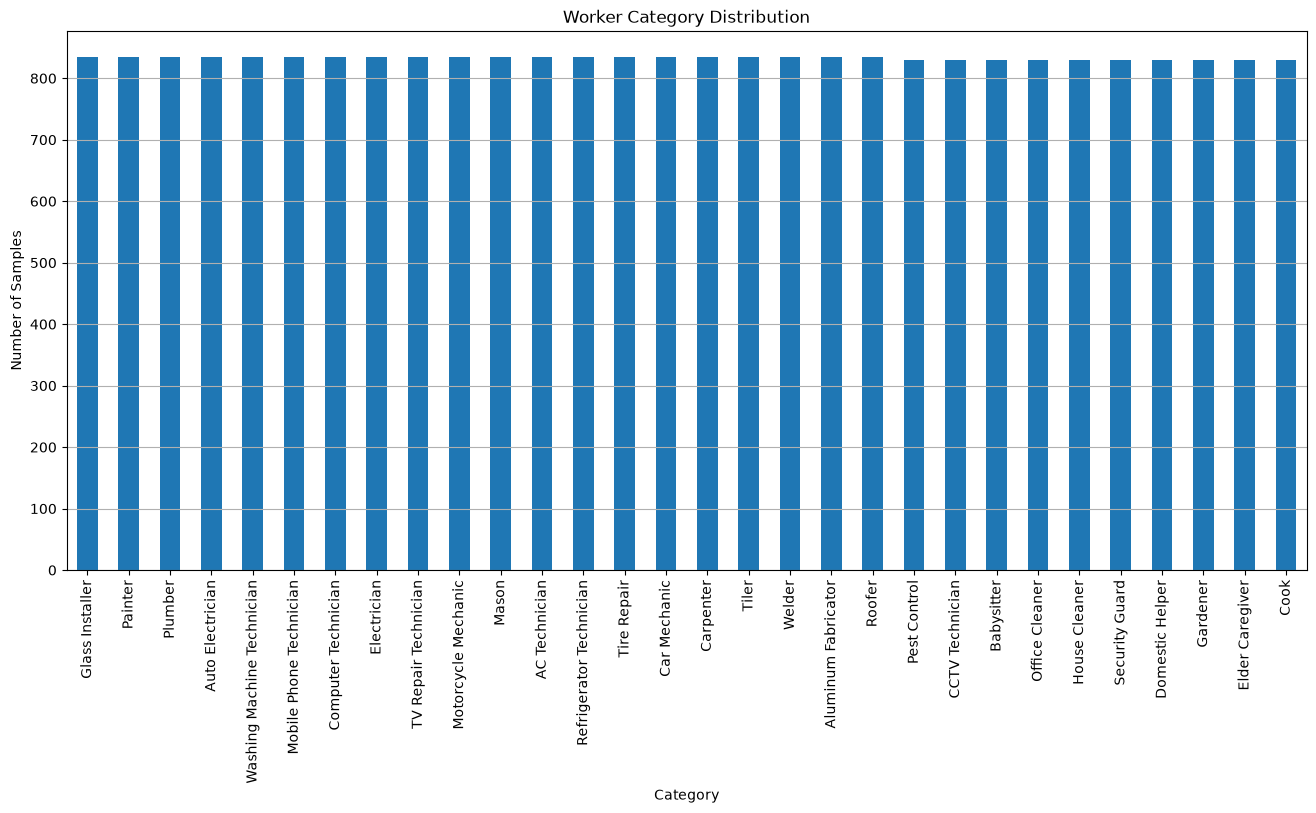

In [33]:
plt.figure(figsize=(16,7))

category_counts.plot(
    kind="bar"
)

plt.title(
    "Worker Category Distribution"
)

plt.xlabel("Category")

plt.ylabel("Number of Samples")

plt.xticks(rotation=90)

plt.grid(axis="y")

plt.show()

Sentence Length

In [34]:
df["text_length"] = df["text"].apply(len)

Sentence Length Statistics

In [35]:
df["text_length"].describe()

count    25000.000000
mean        55.994440
std         13.136195
min         27.000000
25%         46.000000
50%         55.000000
75%         65.000000
max        104.000000
Name: text_length, dtype: float64

Sentence Length Histogram

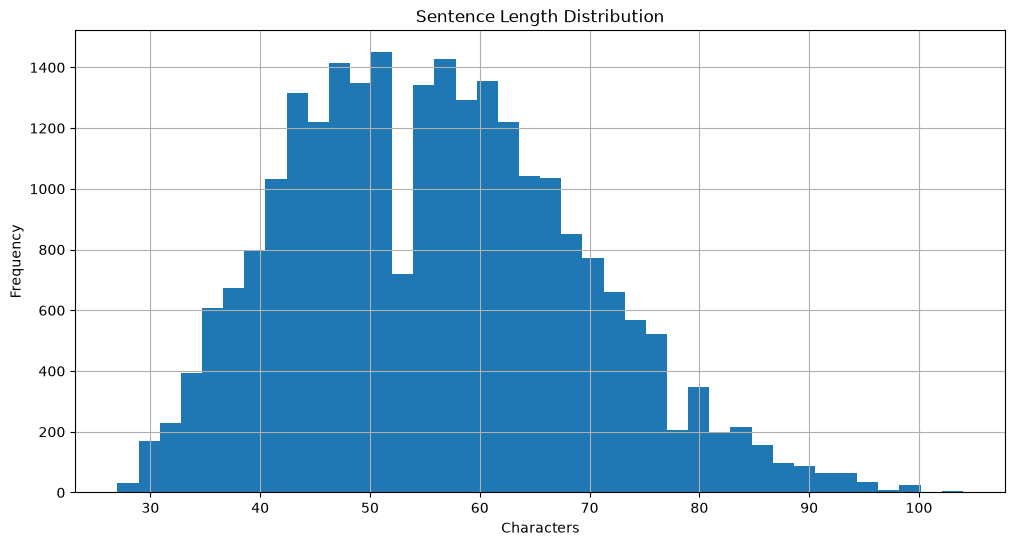

In [36]:
plt.figure(figsize=(12,6))

plt.hist(
    df["text_length"],
    bins=40
)

plt.title(
    "Sentence Length Distribution"
)

plt.xlabel(
    "Characters"
)

plt.ylabel(
    "Frequency"
)

plt.grid()

plt.show()

Shortest Requests

In [37]:
df.sort_values(
    "text_length"
).head(10)

,id,text,category,text_length
15852,15853,I need an experienced cook.,Cook,27
23238,23239,I need an experienced cook.,Cook,27
15730,15731,I need an experienced cook.,Cook,27
2194,2195,I need an experienced cook.,Cook,27
19922,19923,I need an experienced mason.,Mason,28
21997,21998,I would like to hire a cook.,Cook,28
20880,20881,I would like to hire a cook.,Cook,28
21758,21759,I need an experienced tiler.,Tiler,28
4864,4865,I would like to hire a cook.,Cook,28
20764,20765,I would like to hire a cook.,Cook,28


Longest Requests

In [38]:
df.sort_values(
    "text_length",
    ascending=False
).head(10)

,id,text,category,text_length
22252,22253,I'm experiencing a problem because need assist...,Elder Caregiver,104
14303,14304,I'm experiencing a problem because need assist...,Elder Caregiver,104
24309,24310,I'm experiencing a problem because need assist...,Elder Caregiver,104
10054,10055,I'm experiencing a problem because need assist...,Elder Caregiver,104
10516,10517,I'm experiencing a problem because washing cyc...,Washing Machine Technician,100
19277,19278,I'm experiencing a problem because washing cyc...,Washing Machine Technician,100
17095,17096,I'm experiencing a problem because need a care...,Elder Caregiver,100
15582,15583,I'm experiencing a problem because washing cyc...,Washing Machine Technician,100
8692,8693,I'm experiencing a problem because washing cyc...,Washing Machine Technician,100
532,533,I'm experiencing a problem because washing cyc...,Washing Machine Technician,100


Random Samples

In [39]:
df.sample(10, random_state=SEED)

,id,text,category,text_length
6868,6869,I need a car mechanic because the engine is ma...,Car Mechanic,66
24016,24017,Who can help? a wall has developed cracks.,Mason,42
9668,9669,Can anyone help me? the television won't turn on.,TV Repair Technician,49
13640,13641,Please help because my bike won't start.,Motorcycle Mechanic,40
14018,14019,I need someone to help with housework.,Domestic Helper,38
7488,7489,I need someone to check the cooling system.,Refrigerator Technician,43
5804,5805,Need urgent assistance because I need security...,Security Guard,63
12909,12910,cracked wall needs repair. Looking for an expe...,Mason,60
3386,3387,the cement floor needs repair. I need this fix...,Mason,54
9567,9568,Who can help? I need security for an event.,Security Guard,43


Save Clean Dataset

In [40]:
CLEAN_DATASET = OUTPUT_FOLDER / "clean_dataset.csv"

df.to_csv(
    CLEAN_DATASET,
    index=False
)

print(
    f"Saved to:\n{CLEAN_DATASET}"
)

Saved to:
d:\My Files\Software Engineering BSC\Final Project\DEV\OneeAI\outputs\clean_dataset.csv


Summary Report

In [41]:
print("=" * 60)

print("Dataset Summary")

print("=" * 60)

print(f"Rows              : {len(df)}")

print(f"Categories        : {df['category'].nunique()}")

print(f"Average Length    : {df['text_length'].mean():.2f}")

print(f"Shortest Sentence : {df['text_length'].min()}")

print(f"Longest Sentence  : {df['text_length'].max()}")

print("=" * 60)

Dataset Summary
Rows              : 25000
Categories        : 30
Average Length    : 55.99
Shortest Sentence : 27
Longest Sentence  : 104


Load Clean Dataset

In [42]:
CLEAN_DATASET = OUTPUT_FOLDER / "clean_dataset.csv"

df = pd.read_csv(CLEAN_DATASET)

print("Clean dataset loaded successfully.")

Clean dataset loaded successfully.


Preview Dataset

In [43]:
df.head()

,id,text,category,text_length
0,1,I need an experienced glass installer.,Glass Installer,38
1,2,I'm looking for a reliable pest control.,Pest Control,40
2,3,Who is available to repair the CCTV system?,CCTV Technician,43
3,4,Could someone help me to paint the room?,Painter,40
4,5,Need urgent help because water pipe is leaking.,Plumber,47


Check Unique Categories

In [44]:
categories = sorted(df["category"].unique())

print(f"Total Categories : {len(categories)}")

categories

Total Categories : 30


['AC Technician',
 'Aluminum Fabricator',
 'Auto Electrician',
 'Babysitter',
 'CCTV Technician',
 'Car Mechanic',
 'Carpenter',
 'Computer Technician',
 'Cook',
 'Domestic Helper',
 'Elder Caregiver',
 'Electrician',
 'Gardener',
 'Glass Installer',
 'House Cleaner',
 'Mason',
 'Mobile Phone Technician',
 'Motorcycle Mechanic',
 'Office Cleaner',
 'Painter',
 'Pest Control',
 'Plumber',
 'Refrigerator Technician',
 'Roofer',
 'Security Guard',
 'TV Repair Technician',
 'Tiler',
 'Tire Repair',
 'Washing Machine Technician',
 'Welder']

Create Label Encoder

In [45]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["category"])

Verify Encoded Dataset

In [46]:
df.head()

,id,text,category,text_length,label
0,1,I need an experienced glass installer.,Glass Installer,38,13
1,2,I'm looking for a reliable pest control.,Pest Control,40,20
2,3,Who is available to repair the CCTV system?,CCTV Technician,43,4
3,4,Could someone help me to paint the room?,Painter,40,19
4,5,Need urgent help because water pipe is leaking.,Plumber,47,21


Create Label Mapping

In [47]:
label_mapping = pd.DataFrame({

    "Label": range(len(label_encoder.classes_)),

    "Category": label_encoder.classes_

})

label_mapping

,Label,Category
0,0,AC Technician
1,1,Aluminum Fabricator
2,2,Auto Electrician
3,3,Babysitter
4,4,CCTV Technician
5,5,Car Mechanic
6,6,Carpenter
7,7,Computer Technician
8,8,Cook
9,9,Domestic Helper


Verify Encoding

In [48]:
for label, category in enumerate(label_encoder.classes_):

    print(f"{label:2} -> {category}")

 0 -> AC Technician
 1 -> Aluminum Fabricator
 2 -> Auto Electrician
 3 -> Babysitter
 4 -> CCTV Technician
 5 -> Car Mechanic
 6 -> Carpenter
 7 -> Computer Technician
 8 -> Cook
 9 -> Domestic Helper
10 -> Elder Caregiver
11 -> Electrician
12 -> Gardener
13 -> Glass Installer
14 -> House Cleaner
15 -> Mason
16 -> Mobile Phone Technician
17 -> Motorcycle Mechanic
18 -> Office Cleaner
19 -> Painter
20 -> Pest Control
21 -> Plumber
22 -> Refrigerator Technician
23 -> Roofer
24 -> Security Guard
25 -> TV Repair Technician
26 -> Tiler
27 -> Tire Repair
28 -> Washing Machine Technician
29 -> Welder


Category Distribution After Encoding

In [49]:
df.groupby("label").size()

label
0     835
1     835
2     835
3     830
4     830
5     835
6     835
7     835
8     830
9     830
10    830
11    835
12    830
13    835
14    830
15    835
16    835
17    835
18    830
19    835
20    830
21    835
22    835
23    835
24    830
25    835
26    835
27    835
28    835
29    835
dtype: int64

Save Label Mapping

In [50]:
LABEL_MAPPING_PATH = OUTPUT_FOLDER / "label_mapping.csv"

label_mapping.to_csv(

    LABEL_MAPPING_PATH,

    index=False

)

print("Label mapping saved.")

Label mapping saved.


Save Label Encoder

In [51]:
LABEL_ENCODER_PATH = MODEL_FOLDER / "label_encoder.pkl"

joblib.dump(

    label_encoder,

    LABEL_ENCODER_PATH

)

print("Label Encoder Saved Successfully.")

Label Encoder Saved Successfully.


Test Label Encoder

In [52]:
sample_category = "Plumber"

encoded = label_encoder.transform([sample_category])

print(encoded)

[21]


Decode Label

In [53]:
decoded = label_encoder.inverse_transform(encoded)

print(decoded)

['Plumber']


Save Encoded Dataset

In [54]:
ENCODED_DATASET = OUTPUT_FOLDER / "encoded_dataset.csv"

df.to_csv(

    ENCODED_DATASET,

    index=False

)

print("Encoded dataset saved successfully.")

Encoded dataset saved successfully.


Display Dataset Summary

In [55]:
print("=" * 60)

print("Label Encoding Summary")

print("=" * 60)

print(f"Total Samples    : {len(df)}")

print(f"Total Categories : {len(label_encoder.classes_)}")

print(f"Lowest Label     : {df['label'].min()}")

print(f"Highest Label    : {df['label'].max()}")

print("=" * 60)

Label Encoding Summary
Total Samples    : 25000
Total Categories : 30
Lowest Label     : 0
Highest Label    : 29


Load Encoded Dataset

In [56]:
ENCODED_DATASET = OUTPUT_FOLDER / "encoded_dataset.csv"

df = pd.read_csv(ENCODED_DATASET)

print("Encoded dataset loaded successfully.")

Encoded dataset loaded successfully.


Verify Dataset

In [57]:
df.head()

,id,text,category,text_length,label
0,1,I need an experienced glass installer.,Glass Installer,38,13
1,2,I'm looking for a reliable pest control.,Pest Control,40,20
2,3,Who is available to repair the CCTV system?,CCTV Technician,43,4
3,4,Could someone help me to paint the room?,Painter,40,19
4,5,Need urgent help because water pipe is leaking.,Plumber,47,21


Select Features

In [58]:
X = df["text"]

y = df["label"]

First Split (Train 80%, Temp 20%)

In [59]:
X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=SEED,

    stratify=y

)

Second Split (Validation 10%, Test 10%)

In [60]:
X_validation, X_test, y_validation, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=SEED,

    stratify=y_temp

)

Verify Sizes

In [61]:
print("=" * 50)

print("Dataset Split")

print("=" * 50)

print(f"Training Samples   : {len(X_train)}")

print(f"Validation Samples : {len(X_validation)}")

print(f"Testing Samples    : {len(X_test)}")

Dataset Split
Training Samples   : 20000
Validation Samples : 2500
Testing Samples    : 2500


Create DataFrames

In [62]:
train_df = pd.DataFrame({

    "text": X_train,

    "label": y_train

})

validation_df = pd.DataFrame({

    "text": X_validation,

    "label": y_validation

})

test_df = pd.DataFrame({

    "text": X_test,

    "label": y_test
})

Reset Index

In [63]:
train_df.reset_index(

    drop=True,

    inplace=True

)

validation_df.reset_index(

    drop=True,

    inplace=True

)

test_df.reset_index(

    drop=True,

    inplace=True
)

Verify DataFrames

In [64]:
train_df.head()

,text,label
0,I need professional help since I need help wit...,9
1,I'm experiencing a problem because need brick ...,15
2,I need a domestic helper because I need someon...,9
3,Who can help? the freezer is not working.,22
4,Can anyone recommend a good auto electrician?,2


Verify Class Distribution

In [65]:
print(

    train_df["label"].value_counts().sort_index()

)

label
0     668
1     668
2     668
3     664
4     664
5     668
6     668
7     668
8     664
9     664
10    664
11    668
12    664
13    668
14    664
15    668
16    668
17    668
18    664
19    668
20    664
21    668
22    668
23    668
24    664
25    668
26    668
27    668
28    668
29    668
Name: count, dtype: int64


In [66]:
print(

    validation_df["label"].value_counts().sort_index()

)

label
0     84
1     84
2     83
3     83
4     83
5     84
6     83
7     84
8     83
9     83
10    83
11    83
12    83
13    83
14    83
15    84
16    83
17    83
18    83
19    84
20    83
21    83
22    83
23    83
24    83
25    84
26    84
27    84
28    84
29    83
Name: count, dtype: int64


In [67]:
print(

    test_df["label"].value_counts().sort_index()

)

label
0     83
1     83
2     84
3     83
4     83
5     83
6     84
7     83
8     83
9     83
10    83
11    84
12    83
13    84
14    83
15    83
16    84
17    84
18    83
19    83
20    83
21    84
22    84
23    84
24    83
25    83
26    83
27    83
28    83
29    84
Name: count, dtype: int64


Plot Training Distribution

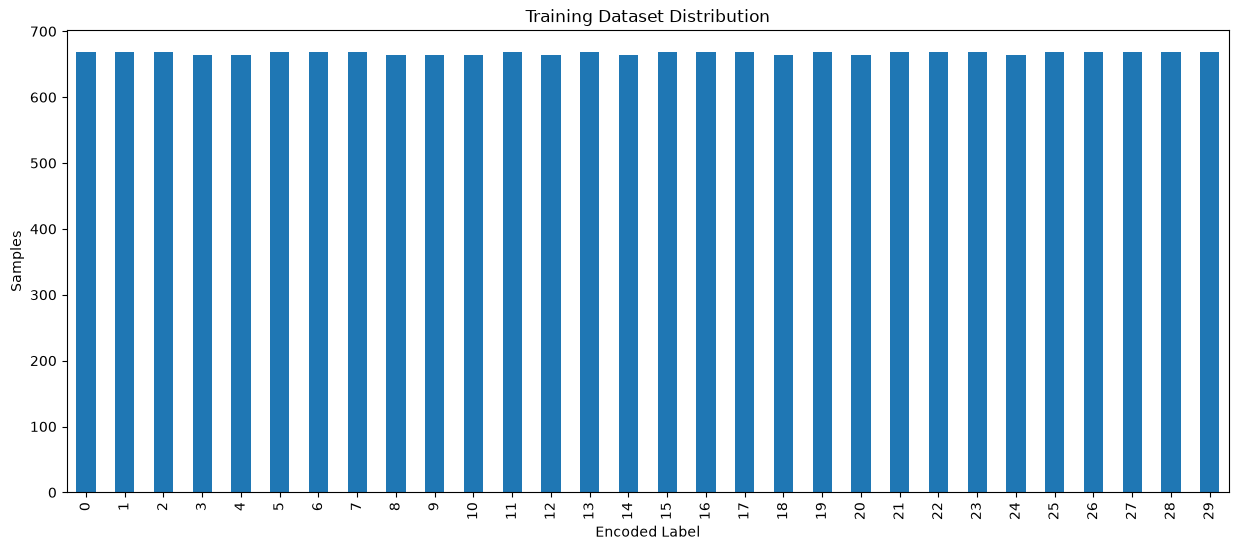

In [68]:
plt.figure(figsize=(15,6))

train_df["label"].value_counts().sort_index().plot(

    kind="bar"

)

plt.title("Training Dataset Distribution")

plt.xlabel("Encoded Label")

plt.ylabel("Samples")

plt.show()

Save CSV Files

In [69]:
train_df.to_csv(

    OUTPUT_FOLDER / "train.csv",

    index=False

)

validation_df.to_csv(

    OUTPUT_FOLDER / "validation.csv",

    index=False

)

test_df.to_csv(

    OUTPUT_FOLDER / "test.csv",

    index=False

)

print("Train/Validation/Test CSV files saved.")

Train/Validation/Test CSV files saved.


Convert to Hugging Face Dataset

In [70]:
train_dataset = Dataset.from_pandas(train_df)

validation_dataset = Dataset.from_pandas(validation_df)

test_dataset = Dataset.from_pandas(test_df)

Verify Dataset Objects

In [71]:
print(train_dataset)

print(validation_dataset)

print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 20000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2500
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2500
})


Display First Record

In [72]:
train_dataset[0]

{'text': 'I need professional help since I need help with daily household chores.',
 'label': 9}

Final Summary

In [73]:
print("=" * 60)

print("Train / Validation / Test Summary")

print("=" * 60)

print(f"Train Samples      : {len(train_df)}")

print(f"Validation Samples : {len(validation_df)}")

print(f"Test Samples       : {len(test_df)}")

print("=" * 60)

Train / Validation / Test Summary
Train Samples      : 20000
Validation Samples : 2500
Test Samples       : 2500


Load Tokenizer

In [74]:
print("Loading DistilBERT Tokenizer...")

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully.")

Loading DistilBERT Tokenizer...
Tokenizer Loaded Successfully.


View Tokenizer Information

In [75]:
print(f"Vocabulary Size : {tokenizer.vocab_size}")

print(f"Model Max Length: {tokenizer.model_max_length}")

print(f"Padding Token   : {tokenizer.pad_token}")

print(f"CLS Token       : {tokenizer.cls_token}")

print(f"SEP Token       : {tokenizer.sep_token}")

Vocabulary Size : 30522
Model Max Length: 512
Padding Token   : [PAD]
CLS Token       : [CLS]
SEP Token       : [SEP]


Define Tokenization Function

In [76]:
def tokenize_function(examples):

    return tokenizer(

        examples["text"],

        truncation=True,

        padding=False,

        max_length=MAX_LENGTH

    )

Tokenize Training Dataset

In [77]:
tokenized_train = train_dataset.map(

    tokenize_function,

    batched=True
)

Map: 100%|██████████| 20000/20000 [00:00<00:00, 26825.00 examples/s]


Tokenize Validation Dataset

In [78]:
tokenized_validation = validation_dataset.map(

    tokenize_function,

    batched=True
)

Map: 100%|██████████| 2500/2500 [00:00<00:00, 25851.25 examples/s]


Tokenize Test Dataset

In [79]:
tokenized_test = test_dataset.map(

    tokenize_function,

    batched=True
)

Map: 100%|██████████| 2500/2500 [00:00<00:00, 27475.09 examples/s]


Verify Tokenized Dataset

In [80]:
print(tokenized_train)

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 20000
})


Inspect First Tokenized Sample

In [81]:
tokenized_train[0]

{'text': 'I need professional help since I need help with daily household chores.',
 'label': 9,
 'input_ids': [101,
  1045,
  2342,
  2658,
  2393,
  2144,
  1045,
  2342,
  2393,
  2007,
  3679,
  4398,
  27091,
  1012,
  102],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Decode Tokens Back to Text

In [82]:
decoded = tokenizer.decode(

    tokenized_train[0]["input_ids"]

)

print(decoded)

[CLS] i need professional help since i need help with daily household chores. [SEP]


Check Sequence Length

In [83]:
print(

    len(tokenized_train[0]["input_ids"])

)

15


Create Dynamic Padding Collator

In [84]:
data_collator = DataCollatorWithPadding(

    tokenizer=tokenizer
)

Verify Data Collator

In [85]:
print(data_collator)

DataCollatorWithPadding(tokenizer=DistilBertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')


Remove Unnecessary Columns

In [86]:
tokenized_train = tokenized_train.remove_columns(["text"])

tokenized_validation = tokenized_validation.remove_columns(["text"])

tokenized_test = tokenized_test.remove_columns(["text"])

Verify Remaining Columns

In [87]:
print(tokenized_train.column_names)

['label', 'input_ids', 'attention_mask']


Set Dataset Format for PyTorch

In [88]:
tokenized_train.set_format(

    type="torch"
)

tokenized_validation.set_format(

    type="torch"
)

tokenized_test.set_format(

    type="torch"
)

Inspect Tensor Sample

In [89]:
sample = tokenized_train[0]

print(sample)

{'label': tensor(9), 'input_ids': tensor([  101,  1045,  2342,  2658,  2393,  2144,  1045,  2342,  2393,  2007,
         3679,  4398, 27091,  1012,   102]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


Summary

In [90]:
print("=" * 60)

print("Tokenization Completed Successfully")

print("=" * 60)

print(f"Training Samples   : {len(tokenized_train)}")

print(f"Validation Samples : {len(tokenized_validation)}")

print(f"Testing Samples    : {len(tokenized_test)}")

print(f"Maximum Length     : {MAX_LENGTH}")

print("=" * 60)

Tokenization Completed Successfully
Training Samples   : 20000
Validation Samples : 2500
Testing Samples    : 2500
Maximum Length     : 64


Import Additional Libraries

In [91]:
import evaluate

from transformers import (
    EarlyStoppingCallback
)

Load Accuracy Metric

In [92]:
accuracy_metric = evaluate.load("accuracy")

Load DistilBERT Model

In [93]:
model = DistilBertForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=len(label_encoder.classes_)

)

model.to(DEVICE)

print("Model Loaded Successfully")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1413.09it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded Successfully


Verify Model

In [94]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

Create Evaluation Function

In [95]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(

        labels,

        predictions,

        average="weighted"

    )

    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

Training Arguments

In [96]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_FOLDER / "checkpoints"),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    logging_dir=str(OUTPUT_FOLDER / "logs"),
    logging_strategy="steps",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Early Stopping

In [97]:
early_stopping = EarlyStoppingCallback(

    early_stopping_patience=2
)

Create Trainer

In [98]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)


Start Training

In [99]:
print("=" * 60)

print("Training Started")

print("=" * 60)

trainer.train()

Training Started


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.010986,0.012011,0.998400,0.998428,0.998400,0.998400
2,0.007850,0.001276,1.000000,1.000000,1.000000,1.000000
3,0.003634,0.000550,1.000000,1.000000,1.000000,1.000000
4,0.002772,0.000438,1.000000,1.000000,1.000000,1.000000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]


TrainOutput(global_step=5000, training_loss=0.11824890394359827, metrics={'train_runtime': 7666.0727, 'train_samples_per_second': 10.436, 'train_steps_per_second': 0.652, 'total_flos': 400793864978880.0, 'train_loss': 0.11824890394359827, 'epoch': 4.0})

Save Training History

In [100]:
history = pd.DataFrame(

    trainer.state.log_history

)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.965969,3.797301,0.000020,0.08,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.598931,3.750356,0.000019,0.16,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.668570,2.222541,0.000019,0.24,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.246214,0.907099,0.000018,0.32,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.100452,0.476212,0.000018,0.40,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Save History CSV

In [101]:
history.to_csv(

    OUTPUT_FOLDER / "training_history.csv",

    index=False

)

print("Training history saved.")

Training history saved.


Plot Training Loss

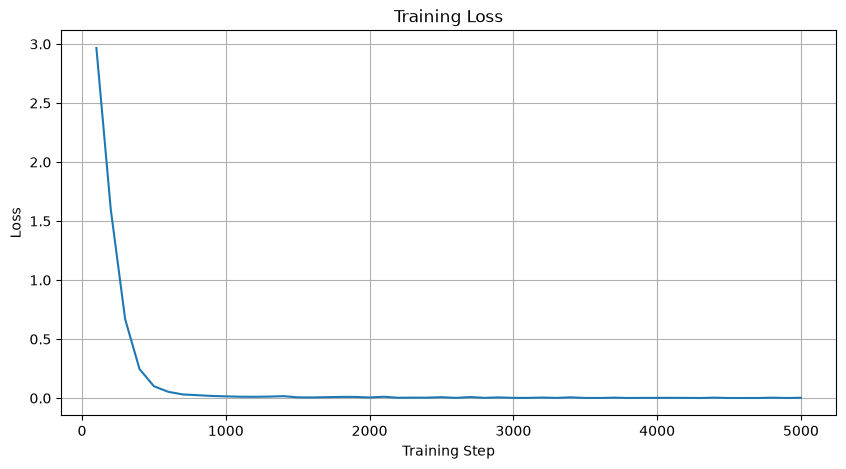

In [102]:
loss_history = history.dropna(

    subset=["loss"]

)

plt.figure(figsize=(10,5))

plt.plot(

    loss_history["step"],

    loss_history["loss"]

)

plt.title("Training Loss")

plt.xlabel("Training Step")

plt.ylabel("Loss")

plt.grid()

plt.show()

Plot Validation Loss

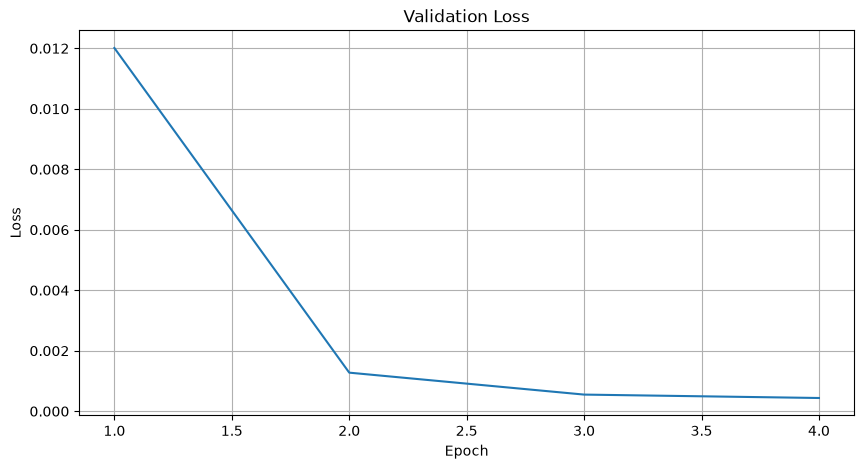

In [103]:
eval_history = history.dropna(

    subset=["eval_loss"]

)

plt.figure(figsize=(10,5))

plt.plot(

    eval_history["epoch"],

    eval_history["eval_loss"]

)

plt.title("Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

Plot Validation Accuracy

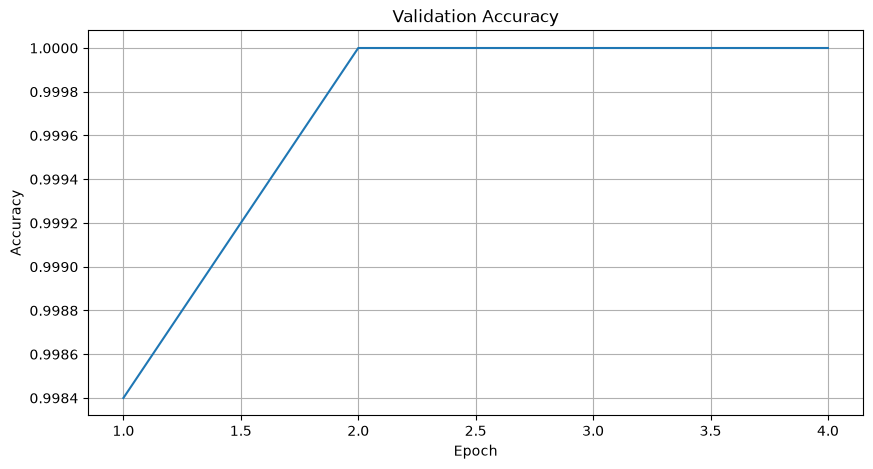

In [104]:
plt.figure(figsize=(10,5))

plt.plot(

    eval_history["epoch"],

    eval_history["eval_accuracy"]

)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid()

plt.show()

Plot Validation F1 Score

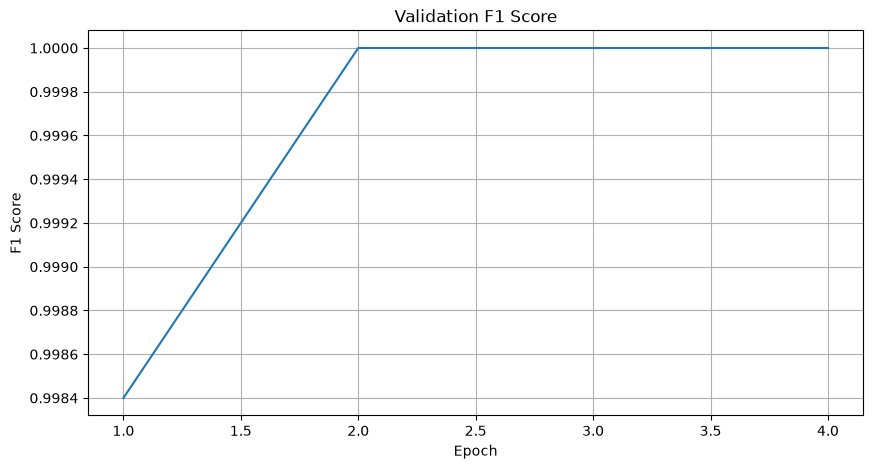

In [105]:
plt.figure(figsize=(10,5))

plt.plot(

    eval_history["epoch"],

    eval_history["eval_f1"]

)

plt.title("Validation F1 Score")

plt.xlabel("Epoch")

plt.ylabel("F1 Score")

plt.grid()

plt.show()

Best Metrics

In [106]:
best = eval_history.sort_values(

    "eval_f1",

    ascending=False

).iloc[0]

print("=" * 60)

print("Best Validation Results")

print("=" * 60)

print(f"Epoch      : {best['epoch']}")

print(f"Accuracy   : {best['eval_accuracy']:.4f}")

print(f"Precision  : {best['eval_precision']:.4f}")

print(f"Recall     : {best['eval_recall']:.4f}")

print(f"F1 Score   : {best['eval_f1']:.4f}")

print("=" * 60)

Best Validation Results
Epoch      : 2.0
Accuracy   : 1.0000
Precision  : 1.0000
Recall     : 1.0000
F1 Score   : 1.0000


Save Checkpoint Information

In [107]:
print("Best Checkpoint")

print(trainer.state.best_model_checkpoint)

Best Checkpoint
d:\My Files\Software Engineering BSC\Final Project\DEV\OneeAI\outputs\checkpoints\checkpoint-2500


Evaluate the Model on the Test Dataset

In [108]:
print("=" * 60)
print("Evaluating Model on Test Dataset")
print("=" * 60)

test_results = trainer.evaluate(tokenized_test)

test_results

Evaluating Model on Test Dataset


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.002772,0.001096,4,1.000000,1.000000,1.000000,1.000000


{'eval_loss': 0.0010956248734146357,
 'eval_accuracy': 1.0,
 'eval_precision': 1.0,
 'eval_recall': 1.0,
 'eval_f1': 1.0}

Display Evaluation Metrics

In [109]:
print("=" * 60)
print("Test Dataset Performance")
print("=" * 60)

print(f"Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"Precision: {test_results['eval_precision']:.4f}")
print(f"Recall   : {test_results['eval_recall']:.4f}")
print(f"F1 Score : {test_results['eval_f1']:.4f}")

print("=" * 60)

Test Dataset Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


Generate Predictions

In [110]:
predictions = trainer.predict(tokenized_test)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

true_labels = predictions.label_ids

Classification Report

In [111]:
report = classification_report(

    true_labels,

    predicted_labels,

    target_names=label_encoder.classes_

)

print(report)

                            precision    recall  f1-score   support

             AC Technician       1.00      1.00      1.00        83
       Aluminum Fabricator       1.00      1.00      1.00        83
          Auto Electrician       1.00      1.00      1.00        84
                Babysitter       1.00      1.00      1.00        83
           CCTV Technician       1.00      1.00      1.00        83
              Car Mechanic       1.00      1.00      1.00        83
                 Carpenter       1.00      1.00      1.00        84
       Computer Technician       1.00      1.00      1.00        83
                      Cook       1.00      1.00      1.00        83
           Domestic Helper       1.00      1.00      1.00        83
           Elder Caregiver       1.00      1.00      1.00        83
               Electrician       1.00      1.00      1.00        84
                  Gardener       1.00      1.00      1.00        83
           Glass Installer       1.00      1.00

Save Classification Report

In [112]:
REPORT_PATH = OUTPUT_FOLDER / "classification_report.txt"

with open(REPORT_PATH, "w", encoding="utf-8") as file:

    file.write(report)

print("Classification report saved.")

Classification report saved.


Create Confusion Matrix

In [113]:
cm = confusion_matrix(

    true_labels,

    predicted_labels
)

Display Confusion Matrix

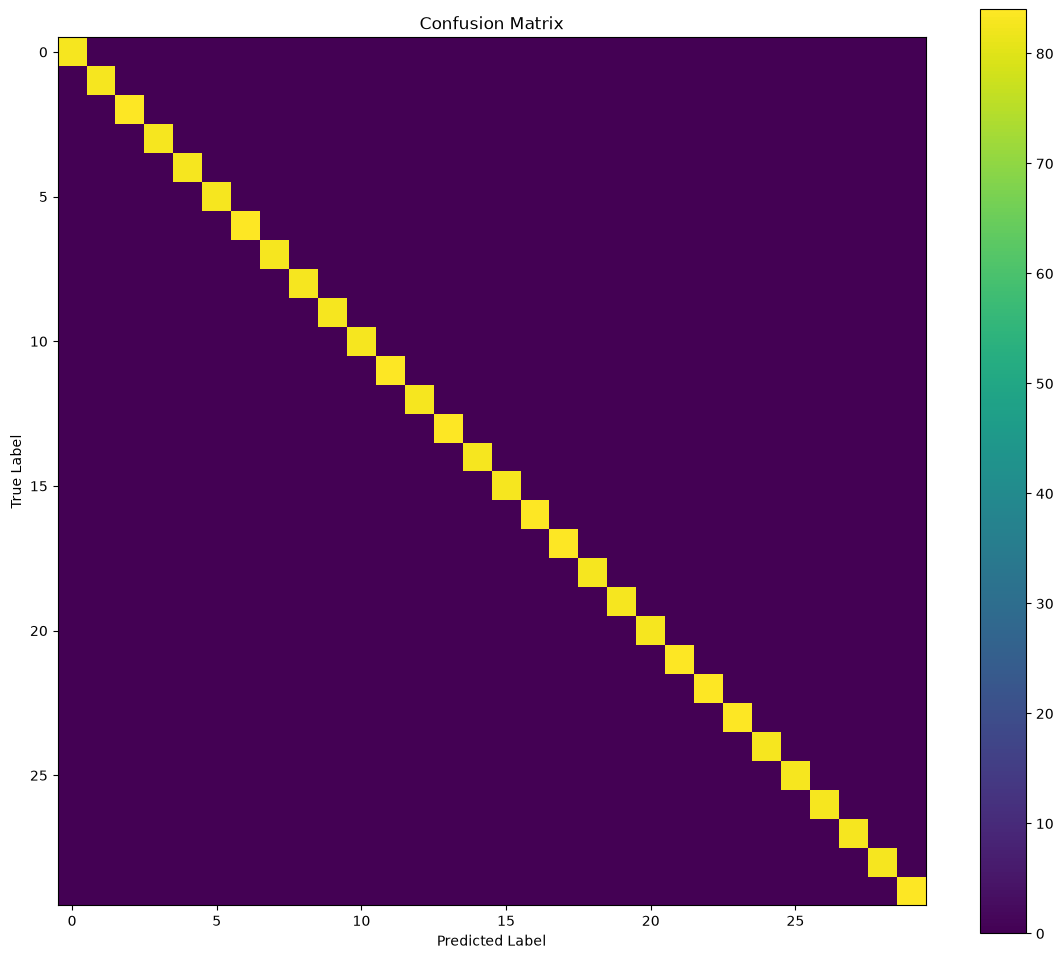

In [114]:
plt.figure(figsize=(14,12))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

Save Confusion Matrix

In [115]:
plt.figure(figsize=(14,12))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(

    OUTPUT_FOLDER / "confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

print("Confusion matrix saved.")

Confusion matrix saved.


Save the Fine-Tuned Model

In [116]:
model.save_pretrained(

    MODEL_FOLDER
)

print("Model saved successfully.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.64it/s]

Model saved successfully.


Save the Tokenizer

In [117]:
tokenizer.save_pretrained(

    MODEL_FOLDER
)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


Verify Deployment Files

In [118]:
print("=" * 60)
print("Files in trained_model/")
print("=" * 60)

for file in sorted(MODEL_FOLDER.iterdir()):

    print(file.name)

Files in trained_model/
config.json
label_encoder.pkl
model.safetensors
tokenizer.json
tokenizer_config.json


Test Loading the Saved Model

In [119]:
saved_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_FOLDER
)

saved_tokenizer = DistilBertTokenizerFast.from_pretrained(
    MODEL_FOLDER
)

print("Saved model loaded successfully.")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2833.58it/s]

Saved model loaded successfully.


Verify Label Encoder

In [120]:
saved_encoder = joblib.load(
    MODEL_FOLDER / "label_encoder.pkl"
)

print(saved_encoder.classes_)

['AC Technician' 'Aluminum Fabricator' 'Auto Electrician' 'Babysitter'
 'CCTV Technician' 'Car Mechanic' 'Carpenter' 'Computer Technician' 'Cook'
 'Domestic Helper' 'Elder Caregiver' 'Electrician' 'Gardener'
 'Glass Installer' 'House Cleaner' 'Mason' 'Mobile Phone Technician'
 'Motorcycle Mechanic' 'Office Cleaner' 'Painter' 'Pest Control' 'Plumber'
 'Refrigerator Technician' 'Roofer' 'Security Guard'
 'TV Repair Technician' 'Tiler' 'Tire Repair' 'Washing Machine Technician'
 'Welder']


Save Evaluation Metrics

In [121]:
evaluation_df = pd.DataFrame([{

    "Accuracy": test_results["eval_accuracy"],

    "Precision": test_results["eval_precision"],

    "Recall": test_results["eval_recall"],

    "F1 Score": test_results["eval_f1"]

}])

evaluation_df.to_csv(

    OUTPUT_FOLDER / "evaluation_metrics.csv",

    index=False

)

evaluation_df

,Accuracy,Precision,Recall,F1 Score
0,1.0,1.0,1.0,1.0


Final Summary

In [122]:
print("=" * 70)

print("Model Development Completed Successfully")

print("=" * 70)

print(f"Training Samples   : {len(tokenized_train)}")
print(f"Validation Samples : {len(tokenized_validation)}")
print(f"Testing Samples    : {len(tokenized_test)}")

print(f"Accuracy           : {test_results['eval_accuracy']:.4f}")
print(f"Precision          : {test_results['eval_precision']:.4f}")
print(f"Recall             : {test_results['eval_recall']:.4f}")
print(f"F1 Score           : {test_results['eval_f1']:.4f}")

print("=" * 70)

Model Development Completed Successfully
Training Samples   : 20000
Validation Samples : 2500
Testing Samples    : 2500
Accuracy           : 1.0000
Precision          : 1.0000
Recall             : 1.0000
F1 Score           : 1.0000


Import Required Libraries

In [123]:
import torch
import joblib
import numpy as np

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

Load Saved Model

In [124]:
MODEL_FOLDER = PROJECT_ROOT / "trained_model"

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_FOLDER
)

tokenizer = DistilBertTokenizerFast.from_pretrained(
    MODEL_FOLDER
)

label_encoder = joblib.load(
    MODEL_FOLDER / "label_encoder.pkl"
)

model.to(DEVICE)

model.eval()

print("Model Loaded Successfully")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3086.53it/s]

Model Loaded Successfully


Verify Loaded Classes

In [125]:
print(label_encoder.classes_)

['AC Technician' 'Aluminum Fabricator' 'Auto Electrician' 'Babysitter'
 'CCTV Technician' 'Car Mechanic' 'Carpenter' 'Computer Technician' 'Cook'
 'Domestic Helper' 'Elder Caregiver' 'Electrician' 'Gardener'
 'Glass Installer' 'House Cleaner' 'Mason' 'Mobile Phone Technician'
 'Motorcycle Mechanic' 'Office Cleaner' 'Painter' 'Pest Control' 'Plumber'
 'Refrigerator Technician' 'Roofer' 'Security Guard'
 'TV Repair Technician' 'Tiler' 'Tire Repair' 'Washing Machine Technician'
 'Welder']


Prediction Function

In [126]:
def predict_service(text):

    encoded = tokenizer(

        text,

        return_tensors="pt",

        truncation=True,

        padding=True,

        max_length=MAX_LENGTH

    )

    encoded = {

        key: value.to(DEVICE)

        for key, value in encoded.items()

    }

    with torch.no_grad():

        outputs = model(**encoded)

    probabilities = torch.softmax(

        outputs.logits,

        dim=1

    )

    confidence, prediction = torch.max(

        probabilities,

        dim=1

    )

    category = label_encoder.inverse_transform(

        prediction.cpu().numpy()

    )[0]

    return {

        "text": text,

        "category": category,

        "confidence": float(confidence)

    }

Test Prediction

In [128]:
sample = "My AC was not working"

result = predict_service(sample)
    
result

{'text': 'My AC was not working',
 'category': 'AC Technician',
 'confidence': 0.9987768530845642}

Pretty Print

In [129]:
print("="*60)

print("Prediction Result")

print("="*60)

print(f"Input      : {result['text']}")

print(f"Category   : {result['category']}")

print(f"Confidence : {result['confidence']:.4f}")

print("="*60)

Prediction Result
Input      : My AC was not working
Category   : AC Technician
Confidence : 0.9988


Top-3 Predictions Function

In [130]:
def predict_top3(text):

    encoded = tokenizer(

        text,

        return_tensors="pt",

        truncation=True,

        padding=True,

        max_length=MAX_LENGTH

    )

    encoded = {

        key: value.to(DEVICE)

        for key, value in encoded.items()

    }

    with torch.no_grad():

        outputs = model(**encoded)

    probabilities = torch.softmax(

        outputs.logits,

        dim=1

    )

    top_probabilities, top_indices = torch.topk(

        probabilities,

        k=3,

        dim=1

    )

    predictions = []

    for probability, index in zip(

        top_probabilities[0],

        top_indices[0]

    ):

        predictions.append({

            "category": label_encoder.inverse_transform(

                [index.cpu().item()]

            )[0],

            "confidence": float(probability)

        })

    return predictions

Test Top-3 Prediction

In [131]:
predict_top3(

    "My air conditioner is not cooling."

)

[{'category': 'AC Technician', 'confidence': 0.9990041851997375},
 {'category': 'Electrician', 'confidence': 0.00011295859439997002},
 {'category': 'Car Mechanic', 'confidence': 7.969305443111807e-05}]

Multiple Test Samples

In [132]:
samples = [

    "My ceiling fan stopped working.",

    "Kitchen sink is leaking badly.",

    "Need house painting.",

    "My washing machine is making loud noise.",

    "Need CCTV installation.",

    "Fix my broken window.",

    "Need gardening service.",

    "Install solar panels.",

    "Need a carpenter to repair my wooden door.",

    "Repair my refrigerator."

]

Predict All Samples

In [133]:
for sample in samples:

    prediction = predict_service(sample)

    print("="*60)

    print(prediction["text"])

    print("Prediction :", prediction["category"])

    print("Confidence :", f"{prediction['confidence']:.4f}")

My ceiling fan stopped working.
Prediction : Electrician
Confidence : 0.9987
Kitchen sink is leaking badly.
Prediction : Plumber
Confidence : 0.9988
Need house painting.
Prediction : Painter
Confidence : 0.9988
My washing machine is making loud noise.
Prediction : Washing Machine Technician
Confidence : 0.9988
Need CCTV installation.
Prediction : CCTV Technician
Confidence : 0.9991
Fix my broken window.
Prediction : Carpenter
Confidence : 0.6269
Need gardening service.
Prediction : Gardener
Confidence : 0.9986
Install solar panels.
Prediction : Electrician
Confidence : 0.6992
Need a carpenter to repair my wooden door.
Prediction : Carpenter
Confidence : 0.9989
Repair my refrigerator.
Prediction : Refrigerator Technician
Confidence : 0.9990


Confidence Threshold

In [134]:
CONFIDENCE_THRESHOLD = 0.70

Safe Prediction Function

In [135]:
def predict_with_threshold(text):

    prediction = predict_service(text)

    if prediction["confidence"] < CONFIDENCE_THRESHOLD:

        prediction["category"] = "Unknown"

    return prediction

Test Threshold

In [136]:
predict_with_threshold(

    "I need some help."

)

{'text': 'I need some help.',
 'category': 'Unknown',
 'confidence': 0.20346590876579285}

Batch Prediction

In [137]:
requests = [

    "Need plumbing service",

    "Fix my AC",

    "Need painter",

    "Repair washing machine"

]

results = [

    predict_service(request)

    for request in requests

]

pd.DataFrame(results)

,text,category,confidence
0,Need plumbing service,Plumber,0.996718
1,Fix my AC,AC Technician,0.998689
2,Need painter,Painter,0.998667
3,Repair washing machine,Washing Machine Technician,0.998627


Save Sample Predictions

In [138]:
prediction_df = pd.DataFrame(results)

prediction_df.to_csv(

    OUTPUT_FOLDER / "sample_predictions.csv",

    index=False

)

print("Sample predictions saved.")

Sample predictions saved.


Final Verification

In [139]:
print("="*60)

print("Inference Pipeline Ready")

print("="*60)

print("Model Loaded")

print("Tokenizer Loaded")

print("Label Encoder Loaded")

print("Prediction Function Ready")

print("Top-3 Prediction Ready")

print("Confidence Threshold Ready")

print("="*60)

Inference Pipeline Ready
Model Loaded
Tokenizer Loaded
Label Encoder Loaded
Prediction Function Ready
Top-3 Prediction Ready
Confidence Threshold Ready
